In [1]:
import os, sys
from pathlib import Path
from pprint import pprint 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bombcell as bc

✅ ipywidgets available - interactive GUI ready


In [2]:
''' File Paths '''
root_dir = "C:/Users/Isabel/Documents/data_temp/"

# session params
bird_id = "LMN88"
session_id = "260716"
ephys_id = "LMN88_260716_132924"

# path to the binary file
intan_folder = f"{root_dir}{bird_id}_{session_id}/{ephys_id}/kilosort4_bc/"

# kilosort directory
ks_dir = f"{intan_folder}/kilosort4"

# Set bombcell's output directory
save_path = Path(intan_folder) / "bombcell"

print(f"Using kilosort directory: {ks_dir}")

Using kilosort directory: C:/Users/Isabel/Documents/data_temp/LMN88_260716/LMN88_260716_132924/kilosort4_bc//kilosort4


In [21]:
''' Quality metrics '''
raw_file_path = f"{intan_folder}/traces_cached_seg0.raw" 
meta_file_path = None 
param = bc.get_default_parameters(ks_dir, 
                                  raw_file=raw_file_path,
                                  meta_file=meta_file_path,
                                  kilosort_version=4,
                                  gain_to_uV=0.195
                                 )

param["nChannels"] = 64
param["nSyncChannels"] = 0
print("Bombcell parameters:")
pprint(param)

Bombcell parameters:
{'computeDistanceMetrics': False,
 'computeDrift': False,
 'computeSpatialDecay': True,
 'computeTimeChunks': False,
 'confidence_threshold': 0.9,
 'contamination_values': None,
 'decompress_data': False,
 'deltaTimeChunk': 360,
 'detrendForUnitMatch': False,
 'detrendWaveform': True,
 'driftBinSize': 60,
 'duplicateSpikeWindow_s': 3.4e-05,
 'ephysKilosortPath': 'C:/Users/Isabel/Documents/data_temp/LMN88_260716/LMN88_260716_132924/kilosort4_bc//kilosort4',
 'ephys_meta_file': None,
 'ephys_sample_rate': 30000,
 'extractRaw': True,
 'gain_to_uV': 0.195,
 'hillOrLlobetMethod': True,
 'isoDmin': 20,
 'lratioMax': 0.3,
 'maxDrift': 100,
 'maxMainPeakToTroughRatio_nonSomatic': 0.8,
 'maxNPeaks': 2,
 'maxNTroughs': 1,
 'maxPeak1ToPeak2Ratio_nonSomatic': 3,
 'maxPercSpikesMissing': 20,
 'maxRPVviolations': 0.1,
 'maxScndPeakToTroughRatio_noise': 0.8,
 'maxSpatialDecaySlopeExp': 0.1,
 'maxWvBaselineFraction': 0.3,
 'maxWvDuration': 1150,
 'minAmplitude': 40,
 'minNumSpikes

In [22]:
''' adjust default params as needed '''
param["maxRPVviolations"] = 0.2
param["computeDrift"] = True
param["splitGoodAndMua_NonSomatic"] = 1
param["minPresenceRatio"] = 0.45;
param["maxWvBaselineFraction"] = 0.5;

param["tauR_values"] = np.arange(0.001, 0.003, 0.00025)

🚀 Starting BombCell quality metrics pipeline...
📁 Processing data from: C:/Users/Isabel/Documents/data_temp/LMN88_260716/LMN88_260716_132924/kilosort4_bc//kilosort4
Results will be saved to: C:\Users\Isabel\Documents\data_temp\LMN88_260716\LMN88_260716_132924\kilosort4_bc\bombcell

Loading ephys data...
Loaded ephys data: 155 units, 4,405,010 spikes

🔍 Extracting raw waveforms...
Loading file C:\Users\Isabel\Documents\data_temp\LMN88_260716\LMN88_260716_132924\kilosort4_bc\bombcell\templates._bc_rawWaveforms.npy... Done!
No splits/merges detected

⚙️ Computing quality metrics for 155 units...
   (Progress bar will appear below)


Computing bombcell quality metrics:   0%|          | 0/155 units


Saving GUI visualization data...
GUI visualization data saved to: C:\Users\Isabel\Documents\data_temp\LMN88_260716\LMN88_260716_132924\kilosort4_bc\bombcell\for_GUI\gui_data.pkl
   Generated spatial decay fits: 155/155 units
   Generated amplitude fits: 155/155 units

🏷️ Classifying units (good/MUA/noise/non-soma)...

Generating summary plots...


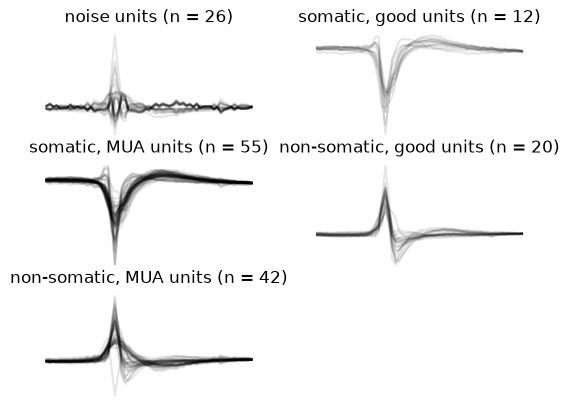

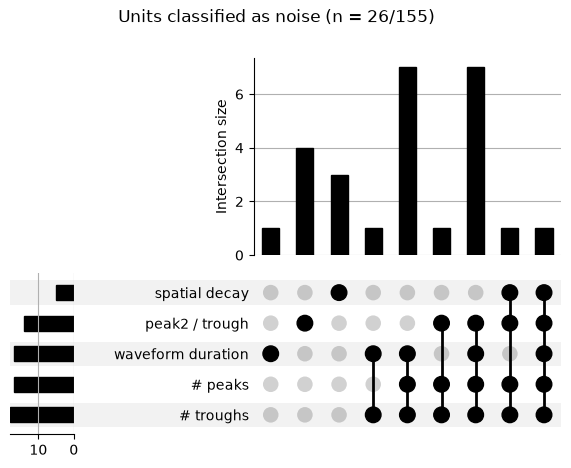

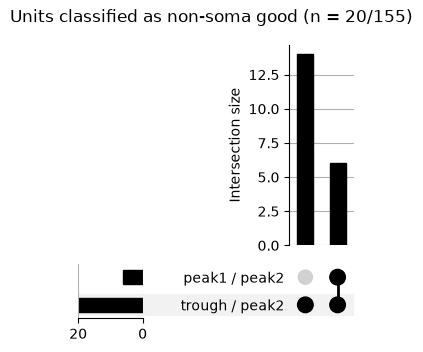

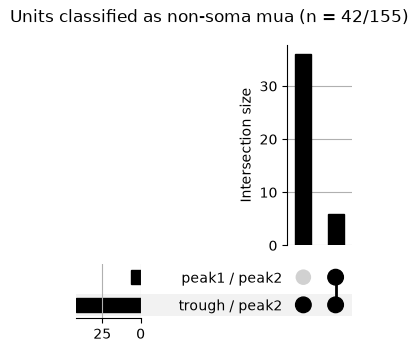

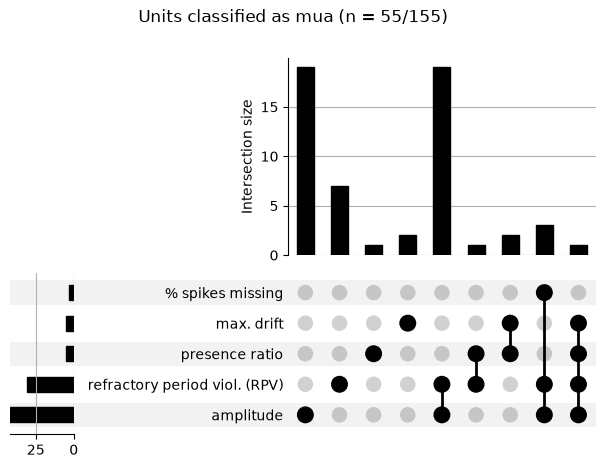

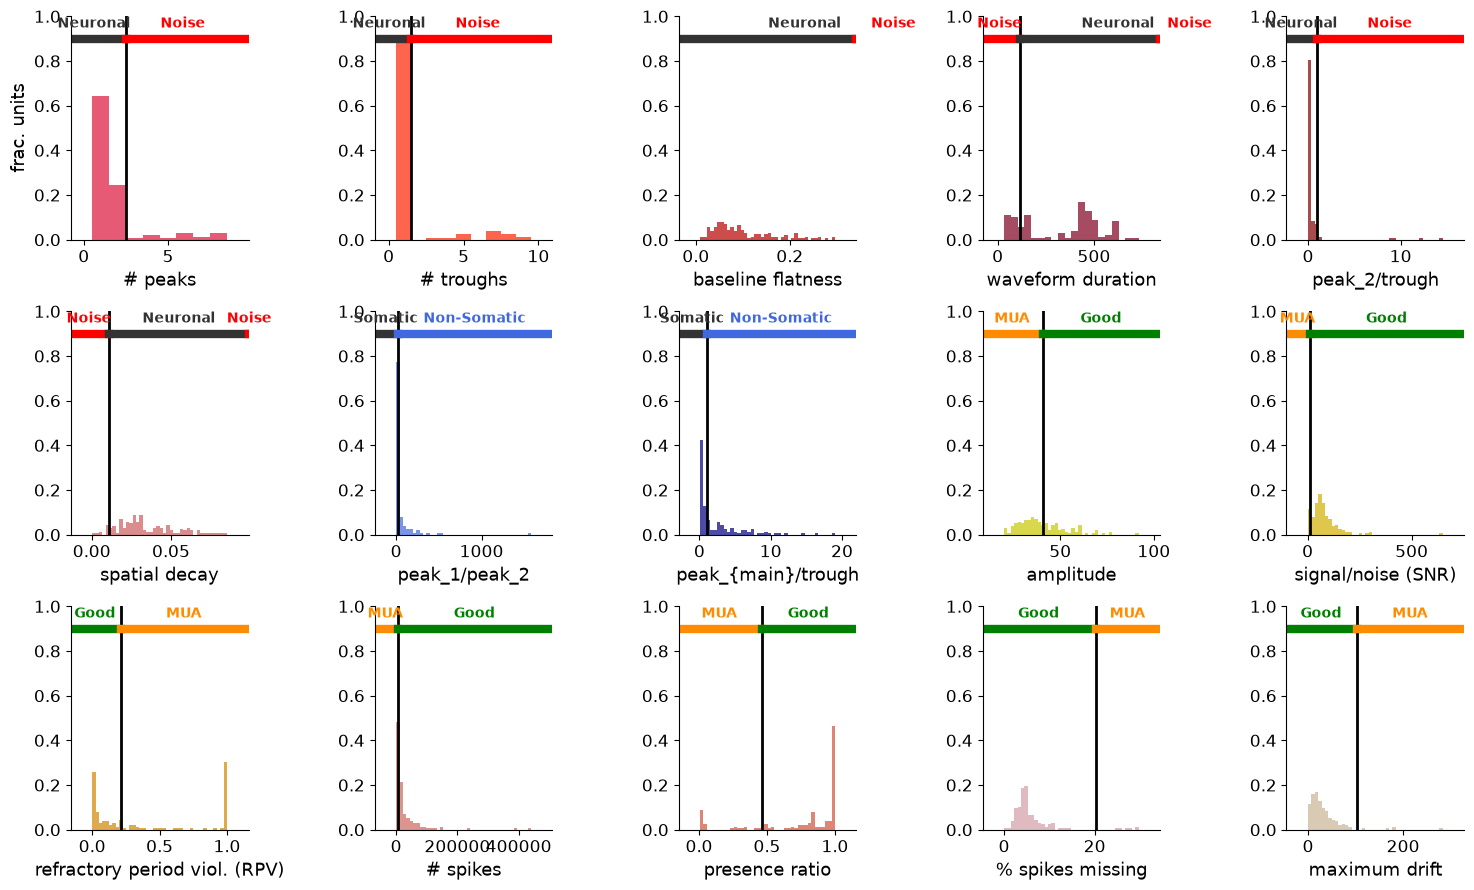


Saving results...
📁 Saving TSV files to Kilosort directory: C:/Users/Isabel/Documents/data_temp/LMN88_260716/LMN88_260716_132924/kilosort4_bc//kilosort4
All expected metrics were successfully saved.


In [23]:
(quality_metrics, param, unit_type, unit_type_string) = bc.run_bombcell(ks_dir, save_path, param)